<a href="https://colab.research.google.com/github/areebaarshadqureshi/Data-Science-Journey-CampusX/blob/main/04-Data-Visualization/01-Matplotlib/02-Advanced-Matplotlib/Matplotlib_Advanced_Tasks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder

plt.style.use('default')

## **Problem 1 to 2:**

**Dataset link:** https://rb.gy/gsmddu

**Add a label to every axis and add a proper title for the charts (For every subplot, it is applicable). Also add proper labels if there are multiple representations.** Then, you can customize it as your wish.

In [ ]:
df=pd.read_csv('https://rb.gy/gsmddu')
df.head()

,Dates,Power Station,Monitored Cap.(MW),Total Cap. Under Maintenace (MW),Planned Maintanence (MW),Forced Maintanence(MW),Other Reasons (MW),Programme or Expected(MU),Actual(MU),Excess(+) / Shortfall (-),Deviation
0,2017-09-01,Delhi,2235.4,135.00,0.00,135.0,0,13,18,5.00,0.0
1,2017-09-01,Haryana,2720.0,2470.00,0.00,2470.0,0,28,7,-21.80,0.0
2,2017-09-01,Himachal Pradesh,3378.0,379.00,0.00,231.0,0,40,46,5.63,0.0
3,2017-09-01,Jammu and Kashmir,1285.0,150.00,0.00,0.0,0,14,23,9.43,0.0
4,2017-09-01,Punjab,3826.3,2697.65,77.65,2620.0,0,39,17,-21.69,0.0


### **Problem-1:** Make a subplots which have 2 plots.

- For the first chart, draw a scatter plot "*Monitored Cap.(MW)*" vs "*Total Cap. Under Maintenance (MW)*" of top 5 most frequent power stations. Then draw the lines which indicate the average values of these two columns. Change the colors according to the names of the Power Stations.
- For the second chart, draw a scatter plot "*Monitored Cap. (MW)*" vs "*Actual(MU)*" of the top 5 most frequent power stations. Also draw the lines which indicates the average values of these two columns. Change the colors according to the names of the Power Stations.


In [ ]:
fps=df['Power Station'].value_counts().sort_values(ascending=False)[:5]
indx=fps.index
data=df[df['Power Station'].isin(indx)]
avg_mon = data['Monitored Cap.(MW)'].mean()
avg_tc = data['Total Cap. Under Maintenace (MW)'].mean()
avg_act = data['Actual(MU)'].mean()
data['Power Station Rank']=data['Power Station'].replace({'NTPC Ltd.':0,'NHPC':1,'NPCIL':2,'GMR ENERG':3,'APL':4})


/tmp/ipython-input-4168353292.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['Power Station Rank']=data['Power Station'].replace({'NTPC Ltd.':0,'NHPC':1,'NPCIL':2,'GMR ENERG':3,'APL':4})
/tmp/ipython-input-4168353292.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Power Station Rank']=data['Power Station'].replace({'NTPC Ltd.':0,'NHPC':1,'NPCIL':2,'GMR ENERG':3,'APL':4})


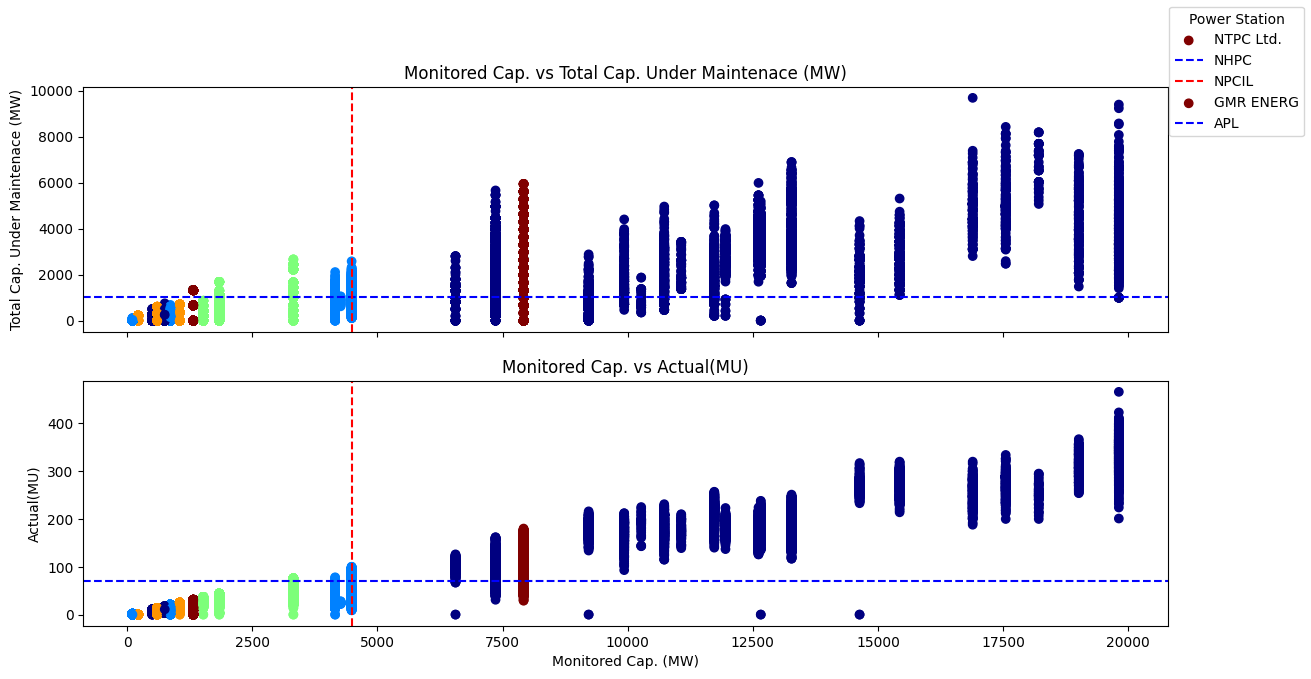

In [ ]:
fig,ax=plt.subplots(nrows=2,ncols=1,sharex=True)
fig.set_size_inches(14,7)
ax[0].scatter(data['Monitored Cap.(MW)'],data['Total Cap. Under Maintenace (MW)'],c=data['Power Station Rank'],cmap='jet')
ax[0].axhline(avg_tc.mean(),color='blue',linestyle='dashed')
ax[0].axvline(avg_mon.mean(),color='red',linestyle='dashed')
ax[0].set_title('Monitored Cap. vs Total Cap. Under Maintenace (MW)')
ax[0].set_ylabel('Total Cap. Under Maintenace (MW)')

ax[1].scatter(data['Monitored Cap.(MW)'],data['Actual(MU)'],c=data['Power Station Rank'],cmap='jet')
ax[1].axhline(avg_act.mean(),color='blue',linestyle='dashed')
ax[1].axvline(avg_mon.mean(),color='red',linestyle='dashed')
ax[1].set_title('Monitored Cap. vs Actual(MU)')
ax[1].set_xlabel('Monitored Cap. (MW)')
ax[1].set_ylabel('Actual(MU)')

fig.legend(fps.index, title='Power Station', loc='upper right')
plt.show()

### **Problem-2:** Draw a 3D Scatter plot between "*Monitored Cap.(MW)*", "*Total Cap. Under Maintenace (MW)*" and "*Forced Maintanence(MW)*"

In [ ]:
df['Power Station Rank'] = df['Power Station'].map(
    df['Power Station'].value_counts().rank(method='first', ascending=False)
)


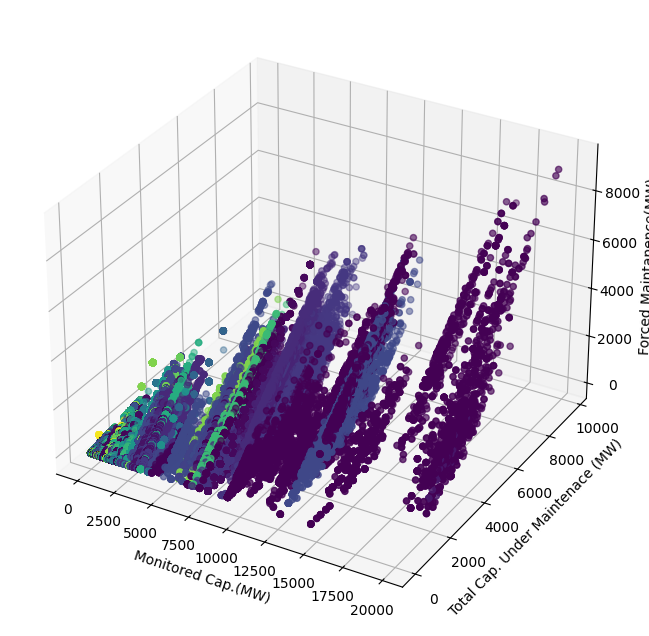

In [ ]:
fig=plt.figure(figsize=(14,8))
ax=fig.add_subplot(projection='3d')
ax.scatter(df['Monitored Cap.(MW)'],df['Total Cap. Under Maintenace (MW)'],df['Forced Maintanence(MW)'],c=df['Power Station Rank'],cmap='viridis')
ax.set_xlabel('Monitored Cap.(MW)')
ax.set_ylabel('Total Cap. Under Maintenace (MW)')
ax.set_zlabel('Forced Maintanence(MW)')
plt.show()

### **Problem-3:** Make a 3D *Surface* plot of this below mathematical equation.

$$z = |x| - |y|$$

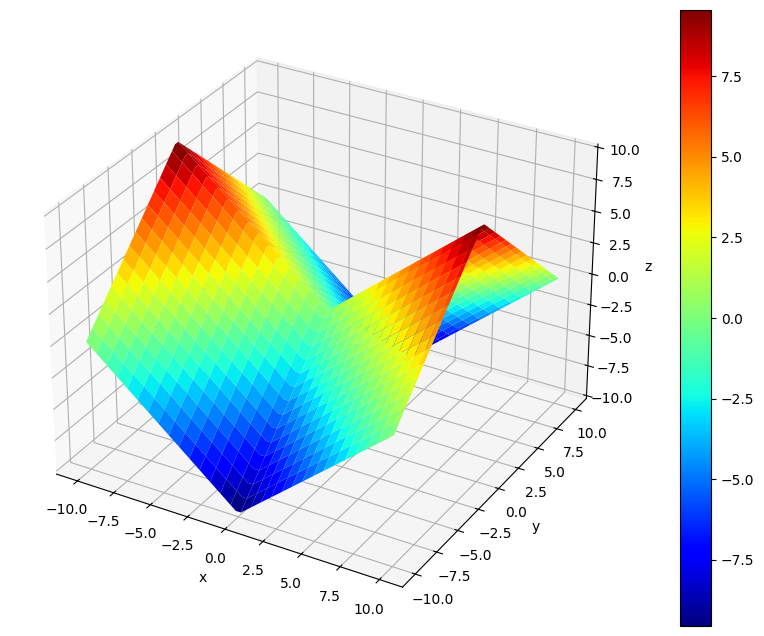

In [ ]:
x=np.linspace(-10,10,60)
y=np.linspace(-10,10,60)
xx,yy=np.meshgrid(x,y)
z=np.abs(xx)-np.abs(yy)

fig=plt.figure(figsize=(14,8))
ax=fig.add_subplot(projection='3d')
p=ax.plot_surface(xx,yy,z,cmap='jet')
fig.colorbar(p)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
plt.show()

### **Problem-4:** Draw the 3D *Contour plot* of this below equation:

$$z = |x| - |y|$$

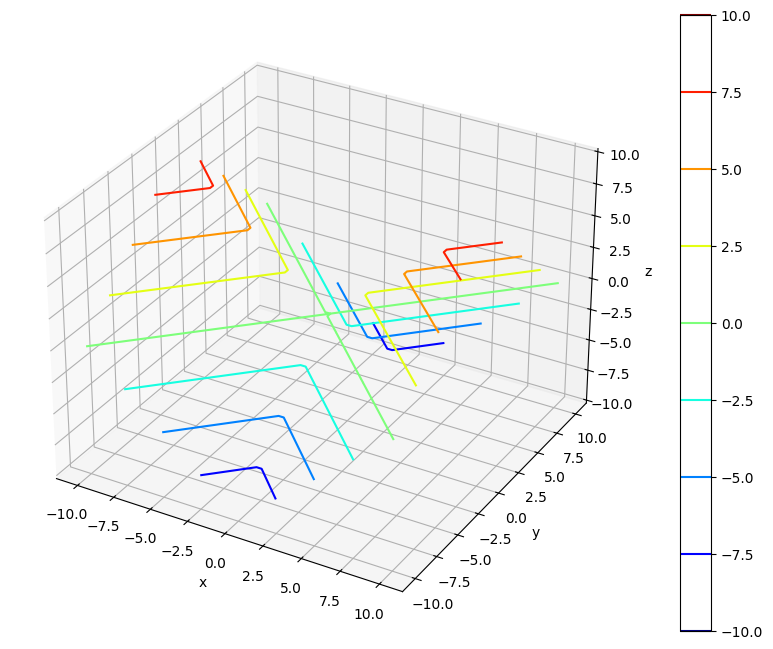

In [ ]:
x=np.linspace(-10,10,60)
y=np.linspace(-10,10,60)
xx,yy=np.meshgrid(x,y)
z=np.abs(xx)-np.abs(yy)

fig=plt.figure(figsize=(14,8))
ax=fig.add_subplot(projection='3d')
p=ax.contour(xx,yy,z,cmap='jet')
fig.colorbar(p)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
plt.show()

### **Problem-5:** Draw a second type of Countour plot of the below equation:

$$z = |x| - |y|$$

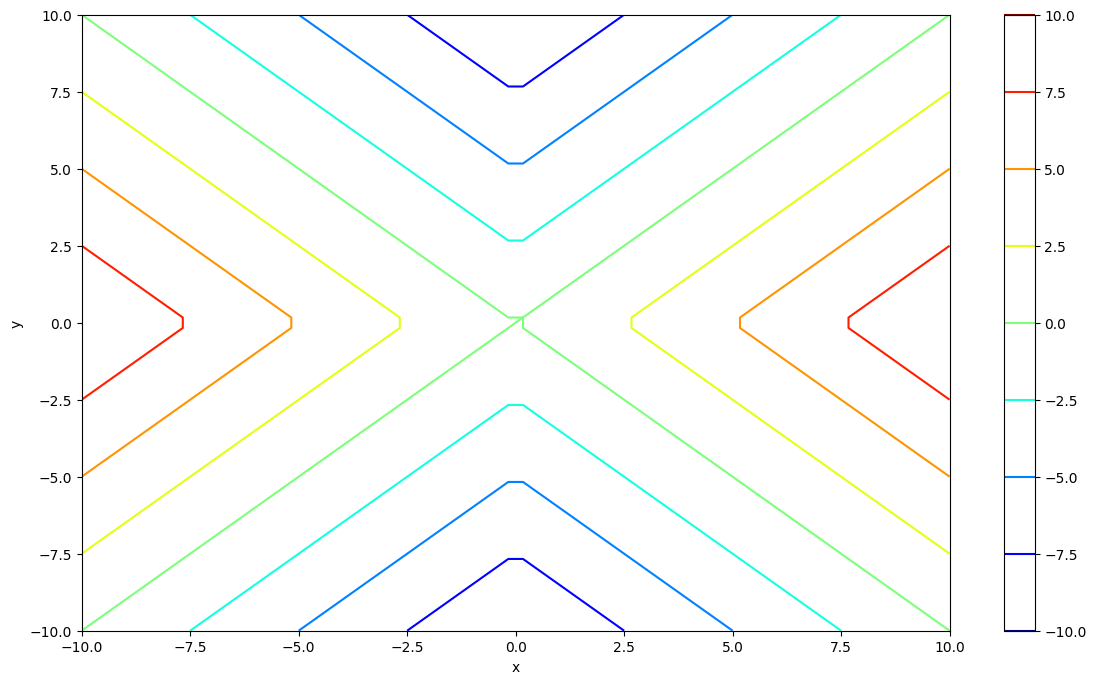

In [ ]:
x=np.linspace(-10,10,60)
y=np.linspace(-10,10,60)
xx,yy=np.meshgrid(x,y)
z=np.abs(xx)-np.abs(yy)

fig=plt.figure(figsize=(14,8))
ax=fig.add_subplot()
p=ax.contour(xx,yy,z,cmap='jet')
fig.colorbar(p)
ax.set_xlabel('x')
ax.set_ylabel('y')
plt.show()

## `Problem 6-7`

Data Set Link - https://docs.google.com/spreadsheets/d/17tUL2yC7MGvo7txuuhLtAI-b6_C4jc0t7FLFxqRm-uI/edit?usp=share_link


**Description of Dataset:**

* Date: It gives the date of which stocks details are given.
* Symbol: Name of stock
* Open: It gives the opening price of stock on that date.
* High: It gives the highest price to which the stock ascened on that day.
* Low: It gives the highest price to which the stock plummeted on that day.
* Close: It gives the closing price of stock on that date.
* Volume: It gives the amount of stock traded on that date.
* VWAP: The volume-weighted average price (VWAP) is a statistic used by traders to determine what the average price is based on both price and volume.
* Turnover:

In [ ]:
df=pd.read_excel('/content/nifty-50.xlsx')
df.head()


,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades
0,2000-01-03,HDFCBANK,EQ,157.40,166.00,170.00,166.00,170.00,170.00,169.52,33259,5.638122e+11,NaN
1,2000-01-04,HDFCBANK,EQ,170.00,182.00,183.45,171.00,174.00,173.80,174.99,168710,2.952261e+12,NaN
2,2000-01-05,HDFCBANK,EQ,173.80,170.00,173.90,165.00,168.00,166.95,169.20,159820,2.704094e+12,NaN
3,2000-01-06,HDFCBANK,EQ,166.95,168.00,170.00,165.30,168.95,168.30,168.44,85026,1.432166e+12,NaN
4,2000-01-07,HDFCBANK,EQ,168.30,162.15,171.00,162.15,170.75,168.35,166.79,85144,1.420158e+12,NaN


### `Problem-6` Use Pandas plot functions

* Line plot of closing value of top 5 Stocks in Year 2020.
* Take top 5 stocks based on total turnover in Year 2020

<Axes: xlabel='Date'>

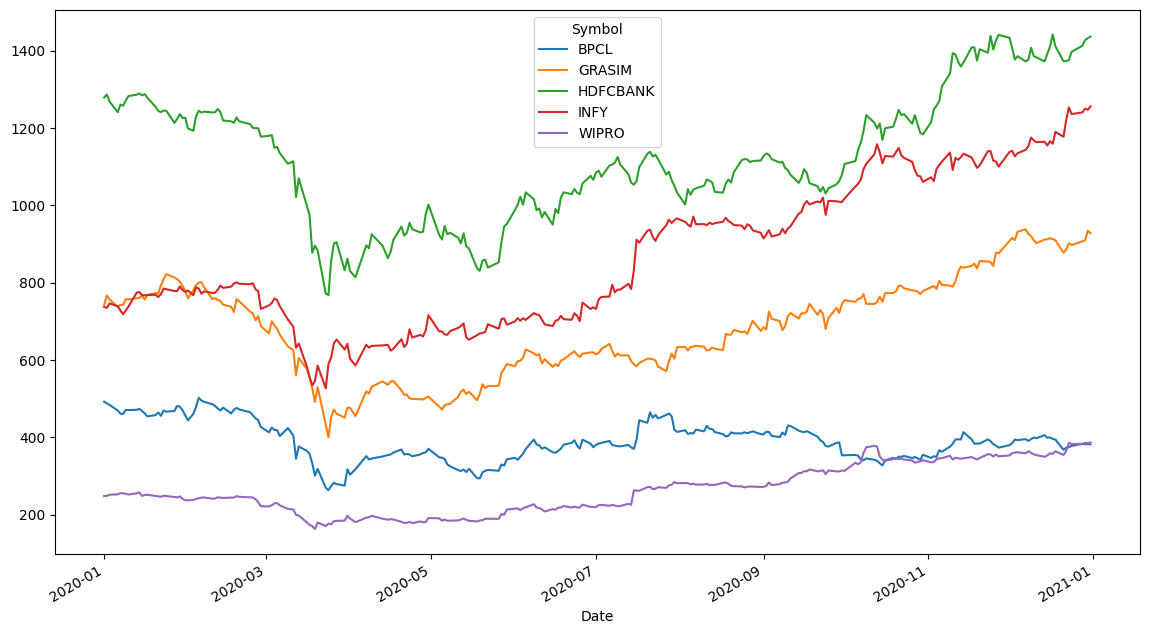

In [ ]:
df['Year']=df['Date'].dt.year
data=df[df['Year']==2020]

stocks=data['Symbol'].value_counts().sort_values(ascending=False)[:5]
data=data[data['Symbol'].isin(stocks.index)]
pivot_data = data.pivot_table(index='Date', columns='Symbol', values='Close')
pivot_data.plot(kind='line',figsize=(14,8))

<Axes: xlabel='Date'>

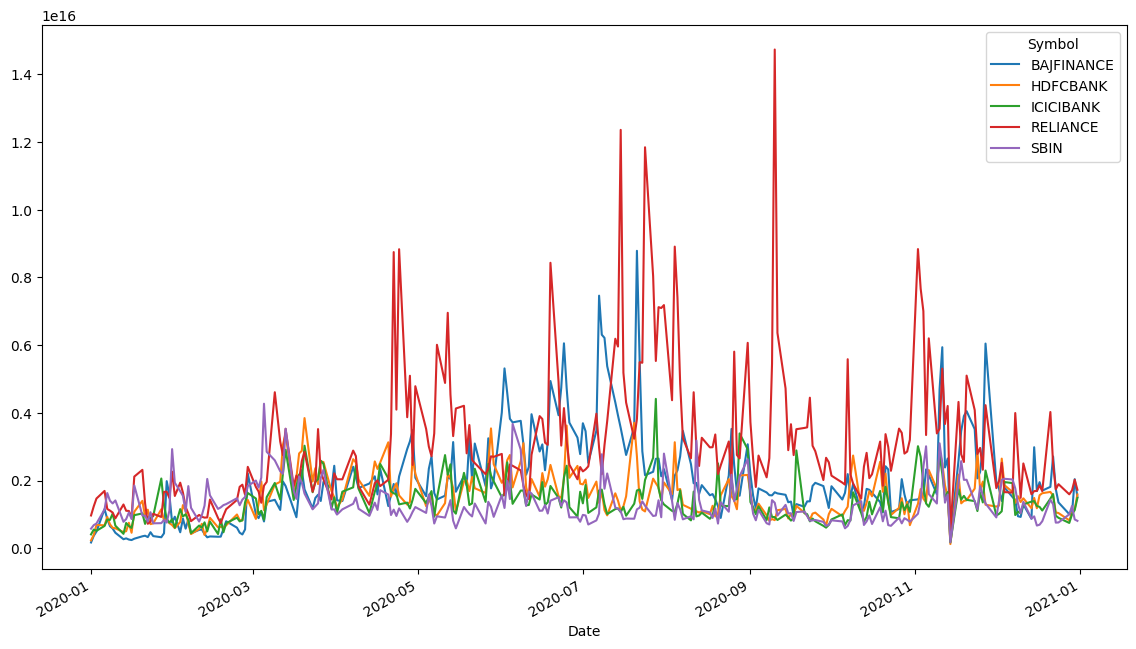

In [ ]:
data=df[df['Year']==2020]
top_t=data.pivot_table(index='Symbol',values='Turnover',aggfunc='sum').sort_values(by='Turnover',ascending=False)[:5]
data=data[data['Symbol'].isin(top_t.index)]
pivot_data=data.pivot_table(index='Date',columns='Symbol',values='Turnover')
pivot_data.plot(kind='line',figsize=(14,8))

### `Problem-7` Scatter plot Close price vs Volume for TOP-5 Stocks in year 2021
* Color on Symbol Column

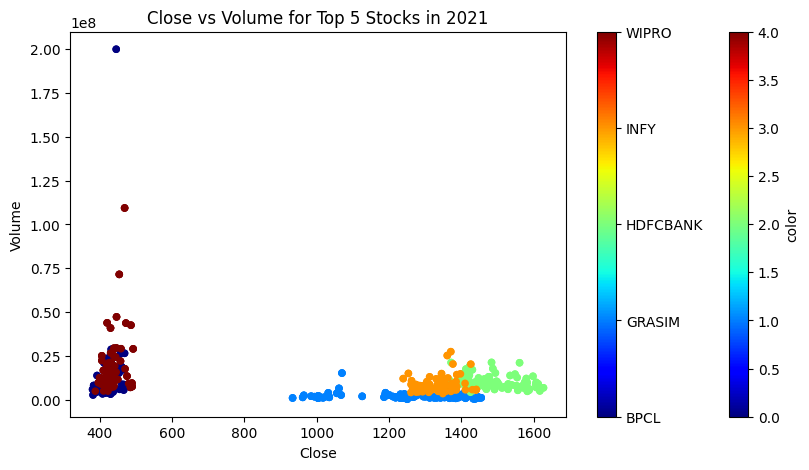

In [ ]:
data=df[df['Year']==2021]

stocks=data['Symbol'].value_counts().sort_values(ascending=False)[:5]
data=data[data['Symbol'].isin(stocks.index)]
encoder = LabelEncoder()
data['color']=encoder.fit_transform(data['Symbol'])
ax=data.plot(kind='scatter',x='Close',y='Volume',title='Close vs Volume for Top 5 Stocks in 2021',c='color',cmap='jet',figsize=(10,5))
# Colorbar with labels
cbar = plt.colorbar(ax.collections[0], ax=ax)
cbar.set_ticks(range(len(stocks)))
cbar.set_ticklabels(encoder.classes_)

### `Problem-8` Create a 3-D Scatter Plot using `time,x,y` on below synthetic data. and give color gradiant on `z`
```
# Create a 3D dataset
time = np.linspace(0, 10, 100)
x = np.sin(time)
y = np.cos(time)
z = time

# Create a DataFrame from the dataset
data = pd.DataFrame({'time': time, 'x': x, 'y': y, 'z': z})
```

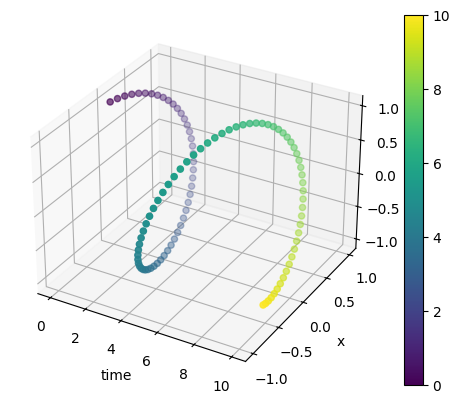

In [ ]:
time = np.linspace(0, 10, 100)
x = np.sin(time)
y = np.cos(time)
z = time
data = pd.DataFrame({'time': time, 'x': x, 'y': y, 'z': z})
fig=plt.figure()
ax=fig.add_subplot(projection='3d')
p=ax.scatter(data['time'],data['x'],data['y'],c=data['z'],cmap='viridis')
ax.set_xlabel('time')
ax.set_ylabel('x')
ax.set_zlabel('y')
c_bar=plt.colorbar(p)
plt.show()


### `Problem 9:` Create a surface plot and the 2 types of the contour plots of the below equation.

$$z = sin(\sqrt{x^2 + y^2})$$


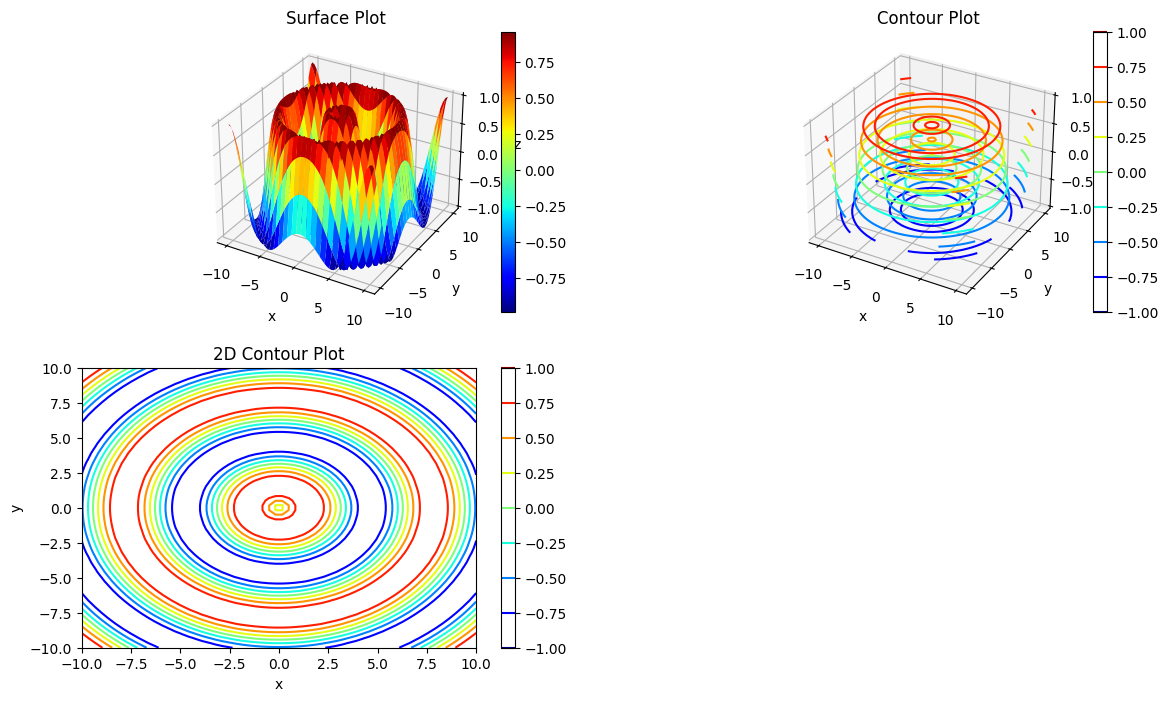

In [ ]:
x=np.linspace(-10,10,60)
y=np.linspace(-10,10,60)
xx,yy=np.meshgrid(x,y)
z=np.sin(np.sqrt(xx**2+yy**2))
fig=plt.figure(figsize=(14,8))

ax1=fig.add_subplot(2,2,1,projection='3d')
p1=ax1.plot_surface(xx,yy,z,cmap='jet')
fig.colorbar(p1,ax=ax1)
ax1.set_title('Surface Plot')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('z')

ax2=fig.add_subplot(2,2,2,projection='3d')
p2=ax2.contour(xx,yy,z,cmap='jet')
fig.colorbar(p2,ax=ax2)
ax2.set_title('Contour Plot')
ax2.set_xlabel('x')
ax2.set_ylabel('y')

ax3=fig.add_subplot(2,2,3)
p3=ax3.contour(xx,yy,z,cmap='jet')
fig.colorbar(p3,ax=ax3)
ax3.set_title('2D Contour Plot')
ax3.set_xlabel('x')
ax3.set_ylabel('y')

plt.show()

### `Problem 10:` Create a surface plot and the 2 types of the contour plots of the below equation.

$$z = tan(\log_2({x^2 + y^2})$$

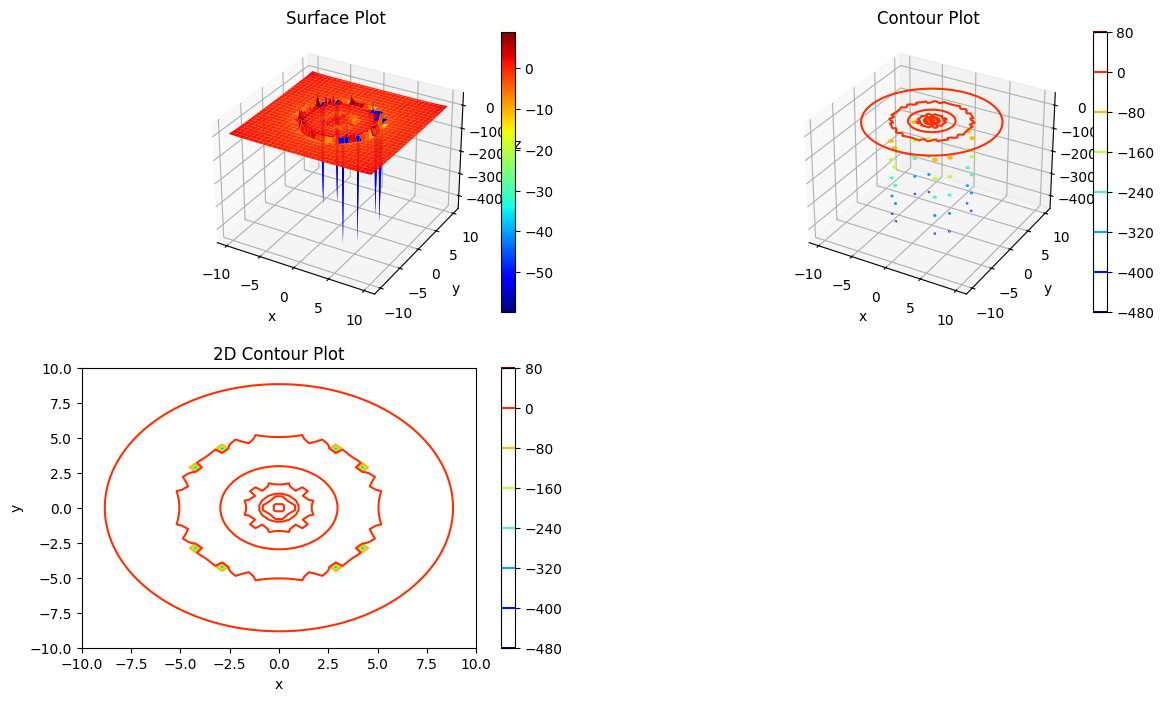

In [ ]:
x=np.linspace(-10,10,60)
y=np.linspace(-10,10,60)
xx,yy=np.meshgrid(x,y)
z=np.tan(np.log2(xx**2+yy**2))
fig=plt.figure(figsize=(14,8))

ax1=fig.add_subplot(2,2,1,projection='3d')
p1=ax1.plot_surface(xx,yy,z,cmap='jet')
fig.colorbar(p1,ax=ax1)
ax1.set_title('Surface Plot')
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('z')

ax2=fig.add_subplot(2,2,2,projection='3d')
p2=ax2.contour(xx,yy,z,cmap='jet')
fig.colorbar(p2,ax=ax2)
ax2.set_title('Contour Plot')
ax2.set_xlabel('x')
ax2.set_ylabel('y')

ax3=fig.add_subplot(2,2,3)
p3=ax3.contour(xx,yy,z,cmap='jet')
fig.colorbar(p3,ax=ax3)
ax3.set_title('2D Contour Plot')
ax3.set_xlabel('x')
ax3.set_ylabel('y')

plt.show()